# Simulación de Inventario 

In [3]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Cargado dataset

In [4]:
df = pd.read_csv("../processed/df_model_CA1.csv")
df["date"] = pd.to_datetime(df["date"])

### Cargando el modelo 

In [5]:
model = joblib.load("demand_forecasting_model.pkl")

In [6]:
features = [
"sell_price",
"is_weekend",
"has_event",
"dayofweek",
"month",
"year",
"lag_7",
"lag_28",
"rolling_mean_7",
"rolling_mean_28"
]

preds = model.predict(df[features])

In [7]:
#Calcular inventario 
daily_demand = preds.mean()
sigma = preds.std()

lead_time = 3
z = 1.65

safety_stock = z * sigma * np.sqrt(lead_time)
reorder_point = daily_demand * lead_time + safety_stock


In [8]:
safety_stock

9.580642320170284

El sistema recomienda mantener 10 unidades extra como protección ante incertidumbre

In [9]:
reorder_point

14.337845541634138

In [10]:
df

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,snap_TX,snap_WI,has_event,sell_price,is_weekend,lag_7,lag_28,rolling_mean_7,rolling_mean_28,dayofweek
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_29,2,2011-02-26,11105,...,0,0,0,2.00,True,1.0,3.0,1.857143,1.392857,5
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_30,2,2011-02-27,11105,...,0,0,0,2.00,True,2.0,0.0,2.000000,1.357143,6
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_31,0,2011-02-28,11105,...,0,0,0,2.00,False,0.0,0.0,2.000000,1.428571,0
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_32,2,2011-03-01,11105,...,1,0,0,2.00,False,2.0,1.0,2.000000,1.428571,1
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_33,1,2011-03-02,11105,...,0,1,0,2.00,False,2.0,4.0,2.000000,1.464286,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617518,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1909,0,2016-04-20,11612,...,0,0,0,5.94,False,0.0,1.0,0.285714,0.357143,2
4617519,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1910,1,2016-04-21,11612,...,0,0,0,5.94,False,1.0,0.0,0.285714,0.321429,3
4617520,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1911,1,2016-04-22,11612,...,0,0,0,5.94,False,1.0,0.0,0.285714,0.357143,4
4617521,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1912,0,2016-04-23,11613,...,0,0,0,5.94,True,0.0,0.0,0.285714,0.392857,5


Cuano el inventario baje ~15 unidades, se debe realizar un pedido.

### Simulación Simple de inventario

In [11]:
item = "FOODS_1_001_CA_1_validation"

item_data = df[df["id"] == item].sort_values("date")

In [12]:
print(item)
print(df["id"].nunique())

FOODS_1_001_CA_1_validation
3049


In [13]:
demand_mean = preds.mean()
demand_std = item_data["sales"].std()

In [14]:
lead_time = 3
service_level = 1.65

initial_inventory = 30
order_quantity = 20

In [15]:
safety_stock = service_level * demand_std * np.sqrt(lead_time)
reorder_point = demand_mean * lead_time + safety_stock

print("Average demand:", round(demand_mean,2))
print("Safety stock:", round(safety_stock,2))
print("Reorder point:", round(reorder_point,2))

Average demand: 1.59
Safety stock: 3.59
Reorder point: 8.35


In [16]:
days = 30

inventory = initial_inventory
inventory_history = []

for d in range(days):

    demand = np.random.poisson(demand_mean)

    inventory -= demand

    if inventory <= reorder_point:
        inventory += order_quantity

    inventory_history.append(inventory)

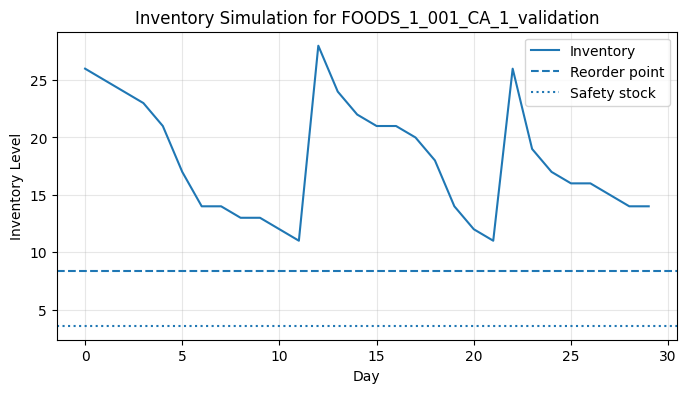

In [17]:
plt.figure(figsize=(8,4))
plt.plot(inventory_history, label="Inventory")
plt.axhline(reorder_point, linestyle="--", label="Reorder point")
plt.axhline(safety_stock, linestyle=":", label="Safety stock")

plt.xlabel("Day")
plt.ylabel("Inventory Level")
plt.title(f"Inventory Simulation for {item}")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Calcular productos Críticos

In [18]:
item_stats = (
    df.groupby("id")["sales"]
    .agg(["mean","std"])
    .reset_index()
)

In [20]:
item_stats.rename(columns={
    "mean":"avg_demand",
    "std":"demand_std"
}, inplace=True)

In [24]:
# eliminar productos con media muy baja
item_stats = item_stats[item_stats["avg_demand"] > 0.1]

In [25]:
item_stats["cv"] = item_stats["demand_std"] / item_stats["avg_demand"]

In [26]:
lead_time = 3

item_stats["expected_demand_lt"] = (
    item_stats["avg_demand"] * lead_time
)

In [27]:
item_stats["inventory_risk"] = (
    item_stats["expected_demand_lt"] * 
    (item_stats["demand_std"] + 1)
)

In [28]:
top_critical = item_stats.sort_values(
    "cv",
    ascending=False
).head(10)

top_critical

,id,avg_demand,demand_std,cv,expected_demand_lt,inventory_risk
2130,HOUSEHOLD_1_133_CA_1_validation,0.915743,6.791070,7.415914,2.747228,21.403849
1995,HOBBIES_2_143_CA_1_validation,0.161150,0.753255,4.674240,0.483451,0.847613
1936,HOBBIES_2_084_CA_1_validation,0.112150,0.499396,4.452945,0.336449,0.504470
1909,HOBBIES_2_057_CA_1_validation,0.164004,0.720906,4.395653,0.492013,0.846708
2695,HOUSEHOLD_2_162_CA_1_validation,0.101194,0.439766,4.345781,0.303582,0.437087
96,FOODS_1_098_CA_1_validation,0.115385,0.487215,4.222527,0.346154,0.514805
470,FOODS_2_256_CA_1_validation,0.104906,0.441792,4.211323,0.314717,0.453756
161,FOODS_1_164_CA_1_validation,0.133333,0.547067,4.103005,0.400000,0.618827
1866,HOBBIES_2_014_CA_1_validation,0.107176,0.436953,4.076962,0.321528,0.462021
2897,HOUSEHOLD_2_365_CA_1_validation,0.104948,0.422088,4.021900,0.314843,0.447734


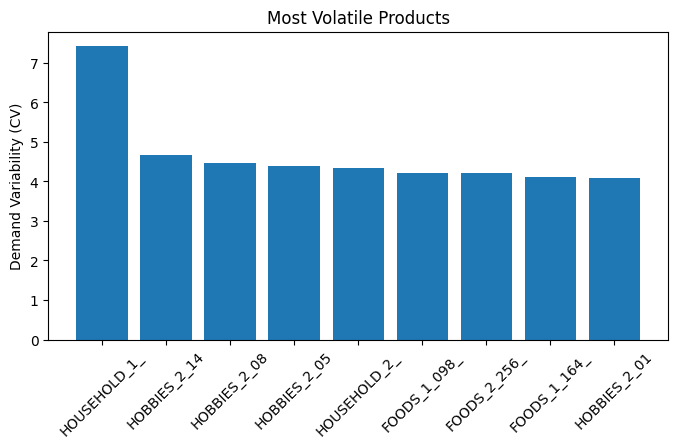

In [29]:
plt.figure(figsize=(8,4))

plt.bar(
    top_critical["id"].str[:12],
    top_critical["cv"]
)

plt.xticks(rotation=45)
plt.ylabel("Demand Variability (CV)")
plt.title("Most Volatile Products")

plt.show()

In [71]:
top_critical.to_csv("../processed/top_critical_products.csv",index=False)